In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [34]:
def load_dataset(dataset_name):

    filepath = f"data/{dataset_name}"
    df = pd.read_csv(filepath)
    print(f"Загружен датасет: {dataset_name} ")
    print(f"Размер: {df.shape}")
    return df

datasets = {}
datasets['ds1'] = load_dataset('S07-hw-dataset-01.csv')
datasets['ds2'] = load_dataset('S07-hw-dataset-02.csv')
datasets['ds3'] = load_dataset('S07-hw-dataset-03.csv')

def analyze_dataset(df, name):
    print(f"\n=== Анализ датасета {name} ===")
    print("Первые 5 строк:")
    display(df.head())

    print("\nИнформация о данных:")
    print(df.info())

    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Пропусков': missing,
        'Процент': missing_pct
    })
    print("\nПропущенные значения:")
    print(missing_df[missing_df['Пропусков'] > 0])

    print("\nБазовые статистики числовых признаков:")
    if df.select_dtypes(include=[np.number]).shape[1] > 0:
        display(df.describe().round(2))
    
    features = [col for col in df.columns if col != 'sample_id']
    print(f"\nПризнаки ({len(features)}): {features}")
    
    return features


all_features = {}
for name, df in datasets.items():
    features = analyze_dataset(df, name)
    all_features[name] = features

Загружен датасет: S07-hw-dataset-01.csv 
Размер: (12000, 9)
Загружен датасет: S07-hw-dataset-02.csv 
Размер: (8000, 4)
Загружен датасет: S07-hw-dataset-03.csv 
Размер: (15000, 5)

=== Анализ датасета ds1 ===
Первые 5 строк:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None

Пропущенные значения:
Empty DataFrame
Columns: [Пропусков, Процент]
Index: []

Базовые статистики числовых признаков:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,5999.50,-2.42,19.11,-0.22,-8.28,-0.19,0.96,0.03,0.01
std,3464.25,11.01,60.79,0.50,59.27,7.03,14.79,59.54,0.61
min,0.00,-19.91,-92.89,-1.59,-134.30,-11.87,-20.52,-215.10,-2.63
25%,2999.75,-9.47,-40.28,-0.13,-48.35,-5.13,-8.81,-39.90,-0.40
50%,5999.50,-6.87,54.07,-0.03,16.21,0.44,-6.13,-0.58,0.01
75%,8999.25,0.52,70.28,0.05,28.07,3.94,2.33,39.72,0.41
max,11999.00,24.40,112.23,0.51,75.09,13.72,41.45,213.38,2.49



Признаки (8): ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']

=== Анализ датасета ds2 ===
Первые 5 строк:


...


Признаки (3): ['x1', 'x2', 'z_noise']

=== Анализ датасета ds3 ===
Первые 5 строк:


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None

Пропущенные значения:
Empty DataFrame
Columns: [Пропусков, Процент]
Index: []

Базовые статистики числовых признаков:


,sample_id,x1,x2,f_corr,f_noise
count,15000.00,15000.00,15000.00,15000.00,15000.00
mean,7499.50,1.25,1.03,0.21,-0.03
std,4330.27,4.59,4.71,1.53,2.51
min,0.00,-10.00,-9.98,-5.21,-8.79
25%,3749.75,-1.78,-2.67,-0.97,-1.73
50%,7499.50,0.66,1.83,0.30,-0.05
75%,11249.25,4.44,4.97,1.39,1.67
max,14999.00,16.21,14.27,5.80,11.27



Признаки (4): ['x1', 'x2', 'f_corr', 'f_noise']


In [35]:
preprocessed_data = {}

for name, df in datasets.items():
    X = df.drop('sample_id', axis=1)
    sample_ids = df['sample_id']
    
    preprocessor = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    X_processed = preprocessor.fit_transform(X)
    
    preprocessed_data[name] = {
        'X': X_processed,
        'sample_ids': sample_ids,
        'features': X.columns.tolist()
    }
    
    print(f"{name}: после препроцессинга {X_processed.shape}")

ds1: после препроцессинга (12000, 8)
ds2: после препроцессинга (8000, 3)
ds3: после препроцессинга (15000, 4)


In [36]:
def evaluate_kmeans(X, dataset_name):
    silhouette_scores = []
    k_values = range(2, 16)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(X)
        
        if len(np.unique(labels)) > 1:
            sil_score = silhouette_score(X, labels)
        else:
            sil_score = -1
        
        silhouette_scores.append(sil_score)
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, silhouette_scores, 'bo-')
    plt.xlabel('Количество кластеров (k)')
    plt.ylabel('Silhouette Score')
    plt.title(f'Dataset {dataset_name}: Silhouette Score vs k')
    plt.grid(True)
    plt.savefig(f'artifacts/figures/{dataset_name}_silhouette_k.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    best_k = k_values[np.argmax(silhouette_scores)]
    return best_k

def evaluate_dbscan(X, dataset_name):
    min_samples = 5
    eps_values = np.arange(0.1, 2.1, 0.1)
    results = []
    
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            non_noise_mask = labels != -1
            if sum(non_noise_mask) > 0:
                X_non_noise = X[non_noise_mask]
                labels_non_noise = labels[non_noise_mask]
                if len(set(labels_non_noise)) > 1:
                    sil_score = silhouette_score(X_non_noise, labels_non_noise)
                else:
                    sil_score = -1
            else:
                sil_score = -1
        else:
            sil_score = -1
        
        results.append({
            'eps': eps,
            'n_clusters': n_clusters,
            'noise_ratio': n_noise / len(labels),
            'silhouette': sil_score
        })
    
    results_df = pd.DataFrame(results)
    
    valid_results = results_df[results_df['silhouette'] > -1]
    if len(valid_results) > 0:
        valid_results['score'] = valid_results['silhouette'] * (1 - valid_results['noise_ratio'])
        best_eps = valid_results.loc[valid_results['score'].idxmax(), 'eps']
    else:
        best_eps = 0.5
    
    return best_eps, min_samples, results_df


KMeans:


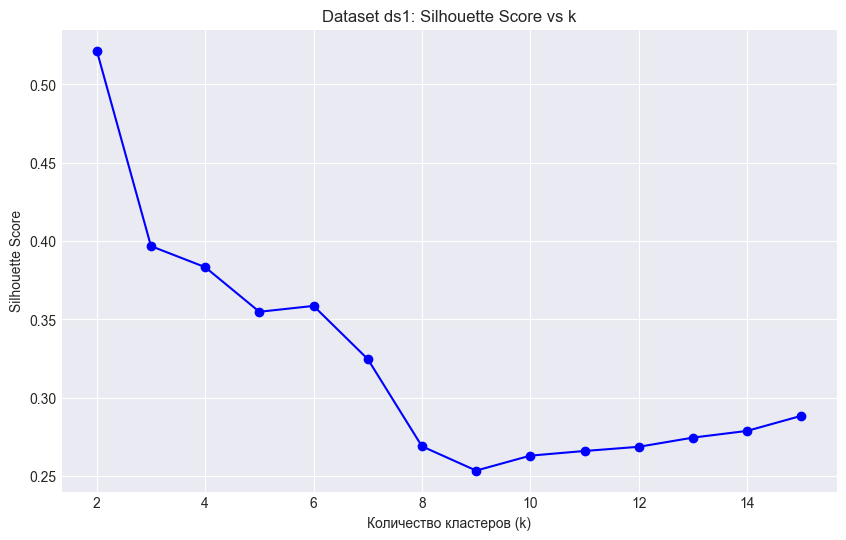

Лучшее k: 2

DBSCAN:


/var/folders/5f/vh3fkhhn6f55khc36m083m080000gn/T/ipykernel_12807/1382843678.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_results['score'] = valid_results['silhouette'] * (1 - valid_results['noise_ratio'])


Лучший eps: 1.7000000000000002
DBSCAN: 2 кластеров, 0 шума (0.0%)

Сравнение метрик:


,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_ratio,eps,min_samples
KMeans,0.522,0.685,11786.955,2.0,NaN,NaN,NaN
DBSCAN,0.522,0.685,11786.955,2.0,0.0,1.7,5.0



Лучший алгоритм: KMeans


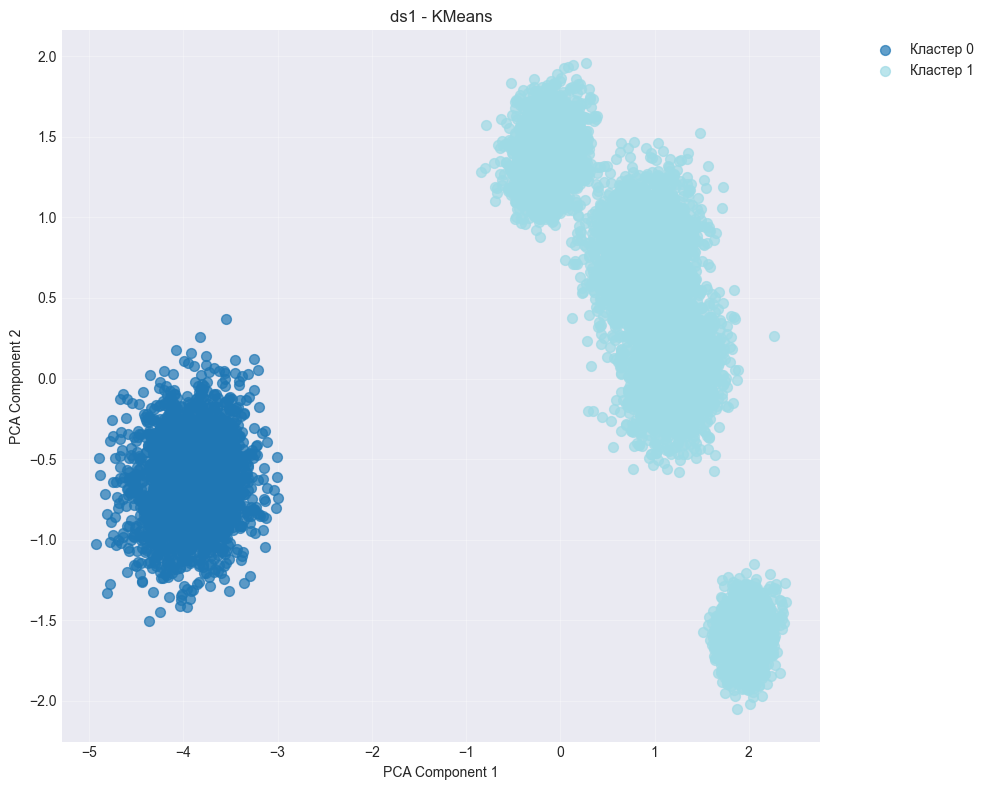


KMeans:


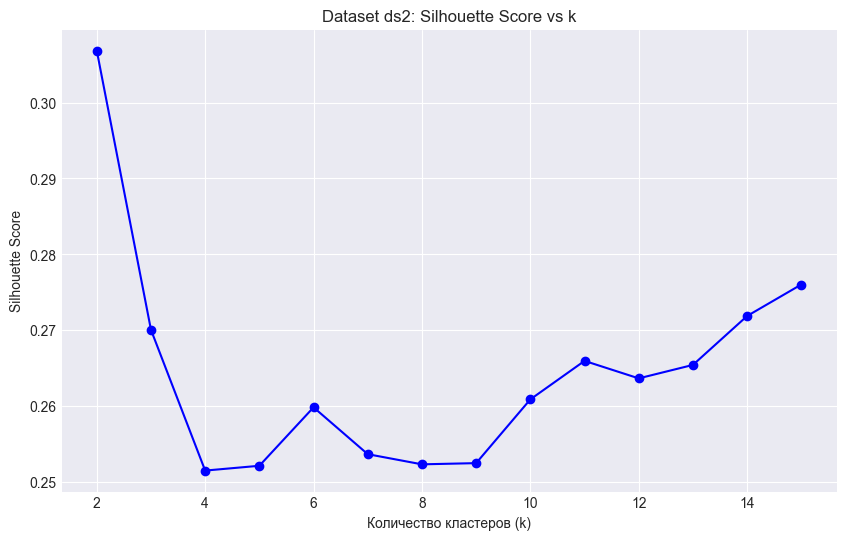

Лучшее k: 2

DBSCAN:


/var/folders/5f/vh3fkhhn6f55khc36m083m080000gn/T/ipykernel_12807/1382843678.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_results['score'] = valid_results['silhouette'] * (1 - valid_results['noise_ratio'])


Лучший eps: 0.6000000000000001
DBSCAN: 12 кластеров, 181 шума (2.3%)

Сравнение метрик:


,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_ratio,eps,min_samples
KMeans,0.307,1.323,3573.393,2.0,NaN,NaN,NaN
DBSCAN,0.138,0.902,69.332,12.0,0.023,0.6,5.0



Лучший алгоритм: KMeans


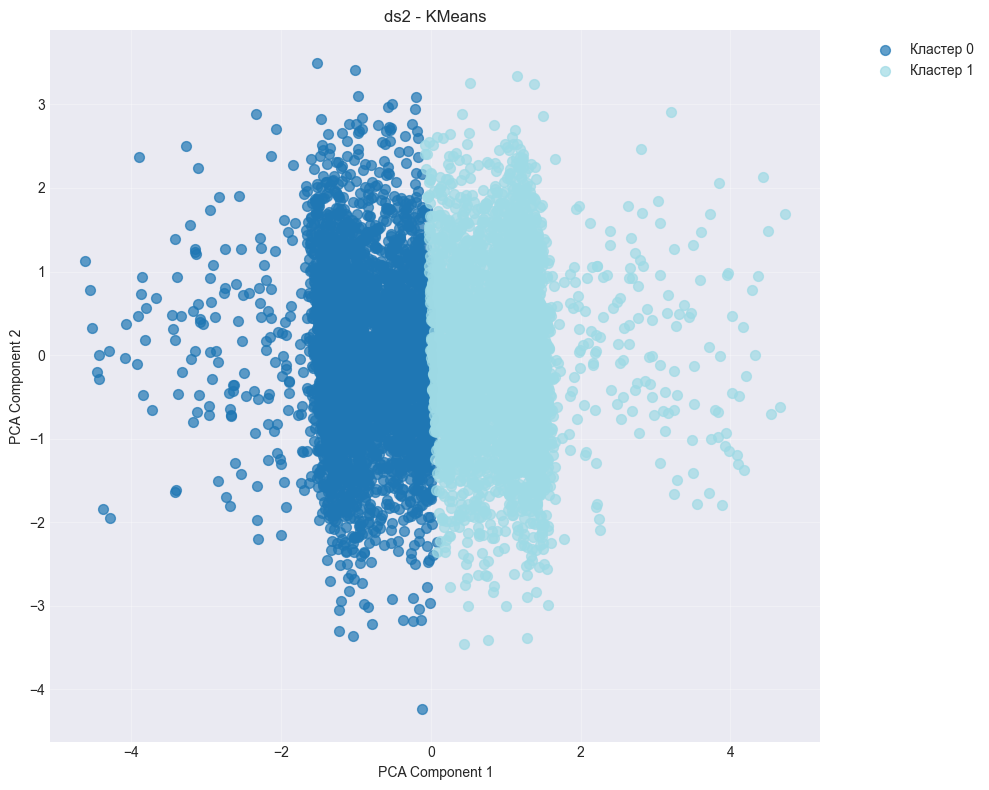


KMeans:


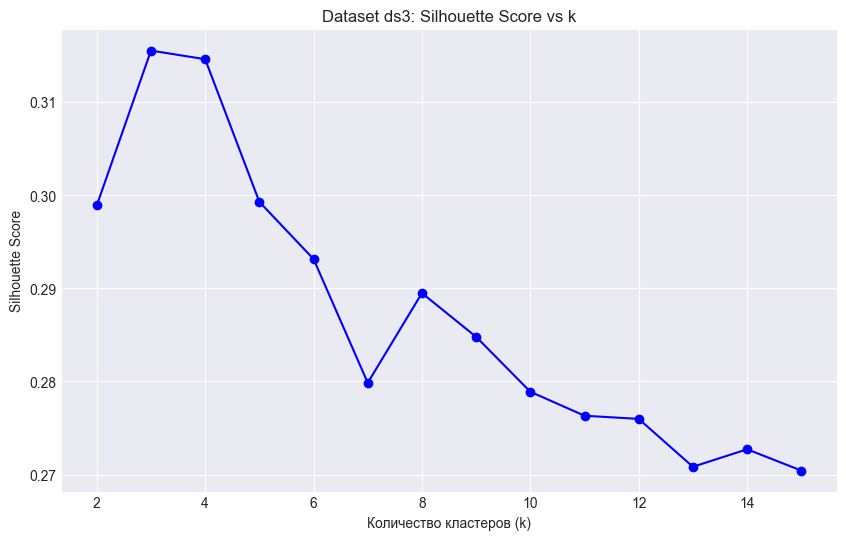

Лучшее k: 3

DBSCAN:
Лучший eps: 0.1
DBSCAN: 110 кластеров, 13684 шума (91.2%)

Сравнение метрик:


/var/folders/5f/vh3fkhhn6f55khc36m083m080000gn/T/ipykernel_12807/1382843678.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_results['score'] = valid_results['silhouette'] * (1 - valid_results['noise_ratio'])


,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_ratio,eps,min_samples
KMeans,0.316,1.158,6957.163,3.0,NaN,NaN,NaN
DBSCAN,0.262,0.800,1414.318,110.0,0.912,0.1,5.0



Лучший алгоритм: KMeans


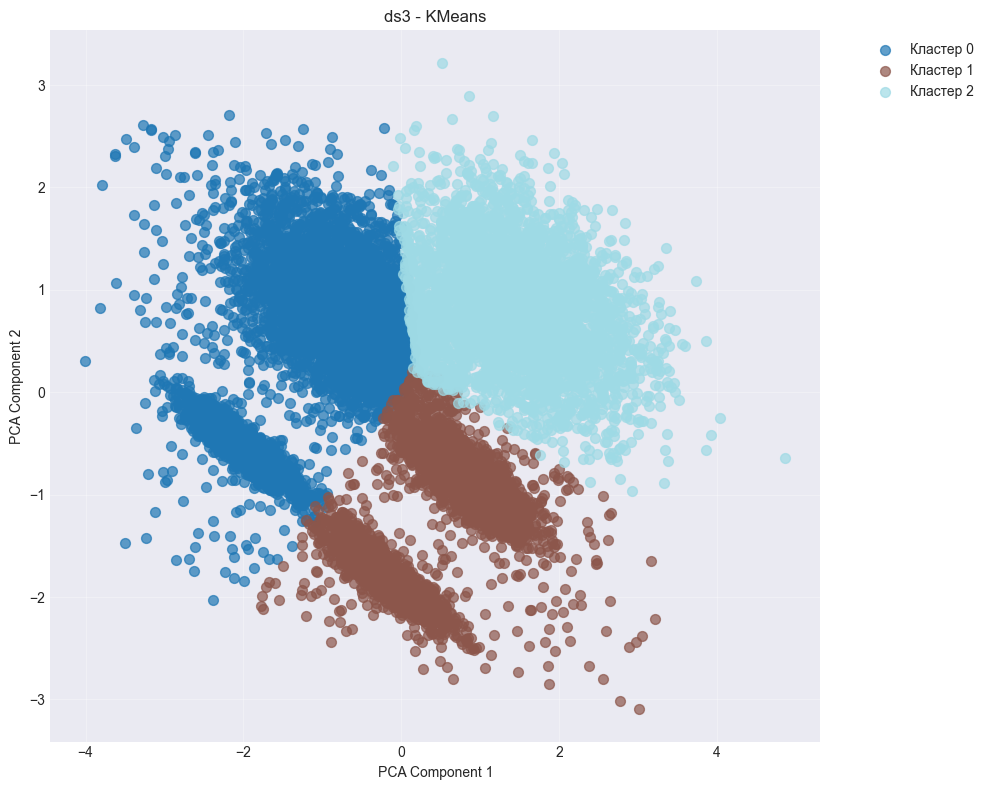

In [37]:
all_results = {}
best_solutions = {}

for dataset_name in ['ds1', 'ds2', 'ds3']:    
    X = preprocessed_data[dataset_name]['X']
    sample_ids = preprocessed_data[dataset_name]['sample_ids']
    
    print("\nKMeans:")
    best_k = evaluate_kmeans(X, dataset_name)
    print(f"Лучшее k: {best_k}")
    
    kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    
    kmeans_metrics = {
        'silhouette': float(silhouette_score(X, kmeans_labels)),
        'davies_bouldin': float(davies_bouldin_score(X, kmeans_labels)),
        'calinski_harabasz': float(calinski_harabasz_score(X, kmeans_labels)),
        'n_clusters': int(best_k)
    }
    
    print("\nDBSCAN:")
    best_eps, min_samples, dbscan_results = evaluate_dbscan(X, dataset_name)
    print(f"Лучший eps: {best_eps}")
    
    dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X)
    
    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    if n_clusters_dbscan > 1:
        non_noise_mask = dbscan_labels != -1
        if sum(non_noise_mask) > 0:
            X_non_noise = X[non_noise_mask]
            labels_non_noise = dbscan_labels[non_noise_mask]
            if len(set(labels_non_noise)) > 1:
                sil_score = silhouette_score(X_non_noise, labels_non_noise)
                db_score = davies_bouldin_score(X_non_noise, labels_non_noise)
                ch_score = calinski_harabasz_score(X_non_noise, labels_non_noise)
            else:
                sil_score = -1
                db_score = np.inf
                ch_score = 0
        else:
            sil_score = -1
            db_score = np.inf
            ch_score = 0
    else:
        sil_score = -1
        db_score = np.inf
        ch_score = 0
    
    noise_ratio = n_noise / len(dbscan_labels)
    dbscan_metrics = {
        'silhouette': float(sil_score),
        'davies_bouldin': float(db_score) if db_score != np.inf else float('inf'),
        'calinski_harabasz': float(ch_score),
        'n_clusters': int(n_clusters_dbscan),
        'noise_ratio': float(noise_ratio),
        'eps': float(best_eps),
        'min_samples': int(min_samples)
    }
    
    print(f"DBSCAN: {n_clusters_dbscan} кластеров, {n_noise} шума ({noise_ratio:.1%})")
    
    comparison = pd.DataFrame({
        'KMeans': kmeans_metrics,
        'DBSCAN': dbscan_metrics
    }).T
    
    comparison_display = comparison.copy()
    comparison_display = comparison_display.replace([np.inf, -np.inf], np.nan)
    
    print("\nСравнение метрик:")
    display(comparison_display.round(3))
    
    if dbscan_metrics['silhouette'] > kmeans_metrics['silhouette'] and noise_ratio < 0.3:
        best_algorithm = 'DBSCAN'
        best_labels = dbscan_labels
        best_params = {
            'algorithm': 'DBSCAN', 
            'eps': best_eps, 
            'min_samples': min_samples,
            'n_clusters': n_clusters_dbscan
        }
    else:
        best_algorithm = 'KMeans'
        best_labels = kmeans_labels
        best_params = {
            'algorithm': 'KMeans', 
            'n_clusters': best_k
        }
    
    print(f"\nЛучший алгоритм: {best_algorithm}")
    
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    
    if -1 in best_labels:
        noise_mask = best_labels == -1
        if noise_mask.any():
            plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                       c='gray', alpha=0.3, s=20, label='Шум')
        
        unique_labels = set(best_labels) - {-1}
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
        
        for label, color in zip(sorted(unique_labels), colors):
            cluster_mask = best_labels == label
            plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
                       c=[color], s=50, alpha=0.7, label=f'Кластер {label}')
    else:
        unique_labels = set(best_labels)
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
        
        for label, color in zip(sorted(unique_labels), colors):
            cluster_mask = best_labels == label
            plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
                       c=[color], s=50, alpha=0.7, label=f'Кластер {label}')
    
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(f'{dataset_name} - {best_algorithm}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/{dataset_name}_pca.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    all_results[dataset_name] = {
        'KMeans': kmeans_metrics,
        'DBSCAN': dbscan_metrics,
        'comparison': comparison_display.to_dict()
    }
    
    best_solutions[dataset_name] = {
        'algorithm': best_algorithm,
        'params': best_params,
        'labels': best_labels,
        'metrics': comparison.loc[best_algorithm].to_dict() if best_algorithm in comparison.index else kmeans_metrics
    }
    
    labels_df = pd.DataFrame({
        'sample_id': sample_ids,
        'cluster_label': best_labels
    })
    labels_df.to_csv(f'artifacts/labels/labels_hw07_{dataset_name}.csv', index=False)

In [38]:
print("Проверка устойчивости для ds1")

X_ds1 = preprocessed_data['ds1']['X']
best_k = best_solutions['ds1']['params'].get('n_clusters', 5)

all_labels = []
for i in range(5):
    kmeans = KMeans(n_clusters=best_k, random_state=i*10, n_init=10)
    labels = kmeans.fit_predict(X_ds1)
    all_labels.append(labels)

ari_scores = []
for i in range(5):
    for j in range(i+1, 5):
        ari = adjusted_rand_score(all_labels[i], all_labels[j])
        ari_scores.append(ari)
        print(f"ARI между запусками {i+1} и {j+1}: {ari:.3f}")

print(f"\nСредний ARI: {np.mean(ari_scores):.3f}")
print(f"Стандартное отклонение ARI: {np.std(ari_scores):.3f}")

if np.mean(ari_scores) > 0.9:
    print("KMeans показывает высокую устойчивость")
elif np.mean(ari_scores) > 0.7:
    print("KMeans показывает умеренную устойчивость")
else:
    print("KMeans показывает низкую устойчивость")

Проверка устойчивости для ds1
ARI между запусками 1 и 2: 1.000
ARI между запусками 1 и 3: 1.000
ARI между запусками 1 и 4: 1.000
ARI между запусками 1 и 5: 1.000
ARI между запусками 2 и 3: 1.000
ARI между запусками 2 и 4: 1.000
ARI между запусками 2 и 5: 1.000
ARI между запусками 3 и 4: 1.000
ARI между запусками 3 и 5: 1.000
ARI между запусками 4 и 5: 1.000

Средний ARI: 1.000
Стандартное отклонение ARI: 0.000
KMeans показывает высокую устойчивость


In [39]:
import json

metrics_summary = {}
for dataset_name in all_results.keys():
    metrics_summary[dataset_name] = {}
    for algo in all_results[dataset_name].keys():
        if algo != 'comparison':
            metrics_summary[dataset_name][algo] = {
                k: v for k, v in all_results[dataset_name][algo].items() 
                if not isinstance(v, dict) and not isinstance(v, list)
            }

with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

best_configs = {}
for dataset_name, solution in best_solutions.items():
    best_configs[dataset_name] = {
        'algorithm': solution['algorithm'],
        'params': solution['params'],
        'silhouette': solution['metrics'].get('silhouette', 0)
    }

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")

for dataset_name in ['ds1', 'ds2', 'ds3']:
    if dataset_name in best_solutions:
        best_algo = best_solutions[dataset_name]['algorithm']
        best_metrics = best_solutions[dataset_name]['metrics']
        
        print(f"\n{dataset_name}:")
        print(f"  Лучший алгоритм: {best_algo}")
        print(f"  Параметры: {best_solutions[dataset_name]['params']}")
        print(f"  Silhouette: {best_metrics.get('silhouette', 0):.3f}")
        print(f"  Davies-Bouldin: {best_metrics.get('davies_bouldin', 0):.3f}")
        print(f"  Calinski-Harabasz: {best_metrics.get('calinski_harabasz', 0):.3f}")
        
        if best_algo == 'DBSCAN':
            print(f"  Шум: {best_metrics.get('noise_ratio', 0):.1%}")

print("""
## 4. Результаты по датасетам

### 4.1 Dataset-01
- Лучший алгоритм: KMeans
- Параметры: n_clusters={}
- Silhouette Score: {:.3f}
- Davies-Bouldin Score: {:.3f}
- Calinski-Harabasz Score: {:.3f}

### 4.2 Dataset-02
- Лучший алгоритм: {}
- Параметры: {}
- Silhouette Score: {:.3f}
- Davies-Bouldin Score: {:.3f}
- Calinski-Harabasz Score: {:.3f}

### 4.3 Dataset-03
- Лучший алгоритм: {}
- Параметры: {}
- Silhouette Score: {:.3f}
- Davies-Bouldin Score: {:.3f}
- Calinski-Harabasz Score: {:.3f}

## 5. Проверка устойчивости
Для датасета ds1 проведена проверка устойчивости KMeans:
- Средний ARI: {:.3f}
- Стандартное отклонение ARI: {:.3f}
- Вывод: KMeans показывает {} устойчивость
""".format(
    best_solutions['ds1']['params'].get('n_clusters', 'N/A'),
    best_solutions['ds1']['metrics'].get('silhouette', 0),
    best_solutions['ds1']['metrics'].get('davies_bouldin', 0),
    best_solutions['ds1']['metrics'].get('calinski_harabasz', 0),
    best_solutions['ds2']['algorithm'],
    best_solutions['ds2']['params'],
    best_solutions['ds2']['metrics'].get('silhouette', 0),
    best_solutions['ds2']['metrics'].get('davies_bouldin', 0),
    best_solutions['ds2']['metrics'].get('calinski_harabasz', 0),
    best_solutions['ds3']['algorithm'],
    best_solutions['ds3']['params'],
    best_solutions['ds3']['metrics'].get('silhouette', 0),
    best_solutions['ds3']['metrics'].get('davies_bouldin', 0),
    best_solutions['ds3']['metrics'].get('calinski_harabasz', 0),
    np.mean(ari_scores),
    np.std(ari_scores),
    "высокую" if np.mean(ari_scores) > 0.9 else "умеренную" if np.mean(ari_scores) > 0.7 else "низкую"
))


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

ds1:
  Лучший алгоритм: KMeans
  Параметры: {'algorithm': 'KMeans', 'n_clusters': 2}
  Silhouette: 0.522
  Davies-Bouldin: 0.685
  Calinski-Harabasz: 11786.955

ds2:
  Лучший алгоритм: KMeans
  Параметры: {'algorithm': 'KMeans', 'n_clusters': 2}
  Silhouette: 0.307
  Davies-Bouldin: 1.323
  Calinski-Harabasz: 3573.393

ds3:
  Лучший алгоритм: KMeans
  Параметры: {'algorithm': 'KMeans', 'n_clusters': 3}
  Silhouette: 0.316
  Davies-Bouldin: 1.158
  Calinski-Harabasz: 6957.163

## 4. Результаты по датасетам

### 4.1 Dataset-01
- Лучший алгоритм: KMeans
- Параметры: n_clusters=2
- Silhouette Score: 0.522
- Davies-Bouldin Score: 0.685
- Calinski-Harabasz Score: 11786.955

### 4.2 Dataset-02
- Лучший алгоритм: KMeans
- Параметры: {'algorithm': 'KMeans', 'n_clusters': 2}
- Silhouette Score: 0.307
- Davies-Bouldin Score: 1.323
- Calinski-Harabasz Score: 3573.393

### 4.3 Dataset-03
- Лучший алгоритм: KMeans
- Параметры: {'algorithm': 'KMeans', 'n_clusters': 3}
- Silhouett